# Analisis E-Commerce Olist — Dampak Keterlambatan Pengiriman terhadap Kepuasan Pelanggan

Analisis atas **99.441 pesanan** pada marketplace Olist (Brasil), periode
September 2016 – Oktober 2018.

## Latar belakang

Olist adalah marketplace yang menghubungkan penjual kecil dengan kanal penjualan besar
di Brasil. Setiap pesanan mencatat tanggal pembelian, tanggal estimasi tiba, tanggal tiba
sebenarnya, serta skor ulasan 1–5 dari pelanggan.

Kombinasi itu memungkinkan satu pertanyaan operasional dijawab secara langsung:

> **Seberapa besar keterlambatan pengiriman merusak kepuasan pelanggan, dan pada hari
> keberapa kerusakannya menjadi serius?**

Pertanyaan turunannya:

1. Berapa persen pesanan yang tiba melebihi tanggal estimasi?
2. Wilayah mana yang paling bermasalah?
3. Kategori produk mana yang menyumbang pendapatan terbesar?
4. Seberapa terkonsentrasi pendapatan pada segelintir penjual?

## Metode

Sembilan berkas CSV dimuat ke **SQLite** (`load_data.py`), sehingga relasi antar tabel
dapat dikueri dengan SQL. Agregasi dilakukan di sisi basis data, sedangkan pandas dan
matplotlib dipakai untuk penyajian.

---

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'figure.autolayout': True,
})

BIRU, MERAH, ABU = '#2563eb', '#dc2626', '#94a3b8'

conn = sqlite3.connect('../olist.db')

def q(sql):
    """Menjalankan query SQL dan mengembalikan DataFrame."""
    return pd.read_sql(sql, conn)

## 1. Ikhtisar data

Memastikan cakupan waktu dan komposisi status pesanan sebelum menarik kesimpulan apa pun.

In [2]:
q('''
    SELECT MIN(date(order_purchase_timestamp)) AS tanggal_awal,
           MAX(date(order_purchase_timestamp)) AS tanggal_akhir,
           COUNT(*)                            AS total_pesanan,
           COUNT(DISTINCT customer_id)         AS total_pelanggan
    FROM orders
''')

,tanggal_awal,tanggal_akhir,total_pesanan,total_pelanggan
0,2016-09-04,2018-10-17,99441,99441


In [3]:
q('''
    SELECT order_status AS status,
           COUNT(*)     AS jumlah,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM orders), 2) AS persen
    FROM orders
    GROUP BY order_status
    ORDER BY jumlah DESC
''')

,status,jumlah,persen
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


**97,0% pesanan berstatus `delivered`.** Analisis selanjutnya dibatasi pada pesanan
yang benar-benar sampai, karena hanya pesanan itu yang punya tanggal tiba sebenarnya
sekaligus skor ulasan.

---

## 2. Seberapa sering pengiriman terlambat?

Sebuah pesanan disebut terlambat bila tanggal tiba melewati tanggal estimasi yang
dijanjikan kepada pelanggan.

In [4]:
q('''
    SELECT COUNT(*) AS pesanan_terkirim,
           SUM(CASE WHEN julianday(order_delivered_customer_date)
                       > julianday(order_estimated_delivery_date)
                    THEN 1 ELSE 0 END) AS pesanan_telat,
           ROUND(100.0 * SUM(CASE WHEN julianday(order_delivered_customer_date)
                       > julianday(order_estimated_delivery_date)
                    THEN 1 ELSE 0 END) / COUNT(*), 2) AS persen_telat,
           ROUND(AVG(julianday(order_delivered_customer_date)
                     - julianday(order_purchase_timestamp)), 1) AS rata_hari_aktual,
           ROUND(AVG(julianday(order_estimated_delivery_date)
                     - julianday(order_purchase_timestamp)), 1) AS rata_hari_dijanjikan
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
''')

,pesanan_terkirim,pesanan_telat,persen_telat,rata_hari_aktual,rata_hari_dijanjikan
0,96470,7826,8.11,12.6,23.7


Dua hal menonjol:

- **8,11% pesanan tiba terlambat** — sekitar 1 dari 12.
- Pengiriman rata-rata butuh **12,6 hari**, padahal yang dijanjikan **23,7 hari**.

Selisih ~11 hari itu menunjukkan estimasi sengaja dilebihkan. Menariknya, meski sudah
diberi cadangan waktu sebesar itu, 8% pesanan tetap lewat tenggat — jadi keterlambatan
yang tercatat di sini bukan sekadar estimasi yang terlalu ketat, melainkan gangguan
logistik yang nyata.

---

## 3. Pertanyaan utama: dampak keterlambatan terhadap ulasan

In [5]:
kategori = q('''
    WITH pengiriman AS (
        SELECT julianday(o.order_delivered_customer_date)
                 - julianday(o.order_estimated_delivery_date) AS selisih,
               r.review_score
        FROM orders o
        JOIN order_reviews r ON r.order_id = o.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    SELECT CASE WHEN selisih <= 0 THEN 'Tepat waktu'
                WHEN selisih <= 3 THEN 'Telat 1-3 hari'
                WHEN selisih <= 7 THEN 'Telat 4-7 hari'
                ELSE                   'Telat >7 hari' END AS kategori,
           COUNT(*)                    AS jumlah,
           ROUND(AVG(review_score), 2) AS rata_skor,
           ROUND(100.0 * SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END)
                 / COUNT(*), 1)        AS persen_ulasan_buruk
    FROM pengiriman
    GROUP BY kategori
    ORDER BY rata_skor DESC
''')
kategori

,kategori,jumlah,rata_skor,persen_ulasan_buruk
0,Tepat waktu,88653,4.29,9.2
1,Telat 1-3 hari,2651,3.77,19.1
2,Telat 4-7 hari,1777,2.32,61.3
3,Telat >7 hari,3272,1.73,78.3


Hubungannya sangat tajam. Pesanan tepat waktu memperoleh rata-rata **4,29**, sedangkan
yang telat lebih dari seminggu hanya **1,73**. Proporsi ulasan buruk melonjak dari
**9,2%** menjadi **78,3%**.

Untuk mengetahui *kapan* tepatnya kepuasan runtuh, keterlambatan dipecah per hari.

Skor turun di bawah netral mulai hari ke-3


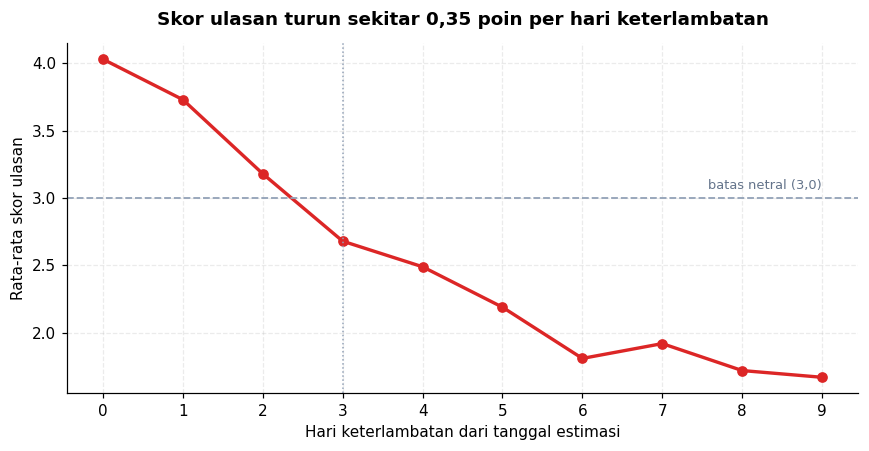

,telat_hari,jumlah,rata_skor
0,0,1291,4.03
1,1,823,3.73
2,2,537,3.18
3,3,496,2.68
4,4,437,2.49
5,5,436,2.19
6,6,408,1.81
7,7,475,1.92
8,8,332,1.72
9,9,219,1.67


In [6]:
harian = q('''
    SELECT CAST(julianday(o.order_delivered_customer_date)
                - julianday(o.order_estimated_delivery_date) AS INT) AS telat_hari,
           COUNT(*)                      AS jumlah,
           ROUND(AVG(r.review_score), 2) AS rata_skor
    FROM orders o
    JOIN order_reviews r ON r.order_id = o.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND julianday(o.order_delivered_customer_date)
          - julianday(o.order_estimated_delivery_date) BETWEEN 0 AND 10
    GROUP BY telat_hari
    ORDER BY telat_hari
''')

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(harian.telat_hari, harian.rata_skor, marker='o', color=MERAH, lw=2.2, ms=6)
ax.axhline(3, color=ABU, lw=1.2, ls='--')
ax.text(harian.telat_hari.max(), 3.07, 'batas netral (3,0)', ha='right',
        color='#64748b', fontsize=8.5)

ambang = int(harian.loc[harian.rata_skor < 3, 'telat_hari'].min())
ax.axvline(ambang, color=ABU, lw=1, ls=':')
ax.set_xlabel('Hari keterlambatan dari tanggal estimasi')
ax.set_ylabel('Rata-rata skor ulasan')
ax.set_title('Skor ulasan turun sekitar 0,35 poin per hari keterlambatan',
             fontweight='bold', pad=12)
ax.set_xticks(range(0, int(harian.telat_hari.max()) + 1))
plt.show()

print(f'Skor turun di bawah netral mulai hari ke-{ambang}')
harian

**Temuan inti.** Penurunan berlangsung hampir linear pada minggu pertama, sekitar
**0,35 poin per hari**. Skor menembus batas netral 3,0 pada **hari ketiga**.

Artinya toleransi pelanggan bukan soal terlambat atau tidak, melainkan soal *seberapa
lama*. Keterlambatan satu hari masih menyisakan skor 3,73 — masih positif. Pada hari
ketiga, rata-rata sudah jatuh ke 2,68 dan ulasan berubah menjadi negatif.

---

## 4. Wilayah mana yang bermasalah?

In [7]:
wilayah = q('''
    SELECT cu.customer_state AS negara_bagian,
           COUNT(*)          AS pesanan,
           ROUND(AVG(julianday(o.order_delivered_customer_date)
                     - julianday(o.order_purchase_timestamp)), 1) AS rata_hari,
           ROUND(100.0 * SUM(CASE WHEN julianday(o.order_delivered_customer_date)
                        > julianday(o.order_estimated_delivery_date)
                     THEN 1 ELSE 0 END) / COUNT(*), 1)            AS persen_telat,
           ROUND(AVG(r.review_score), 2)                          AS rata_skor
    FROM orders o
    JOIN customers     cu ON cu.customer_id = o.customer_id
    JOIN order_reviews r  ON r.order_id     = o.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY negara_bagian
    HAVING COUNT(*) >= 500
    ORDER BY persen_telat DESC
''')
wilayah.head(12)

,negara_bagian,pesanan,rata_hari,persen_telat,rata_skor
0,MA,716,21.4,19.1,3.84
1,CE,1276,21.2,15.3,3.94
2,BA,3246,19.3,13.8,3.93
3,RJ,12281,15.3,13.3,3.96
4,ES,1978,15.6,11.9,4.08
5,PA,939,23.6,11.8,3.91
6,MS,710,15.6,11.5,4.17
7,PB,513,20.2,10.7,4.08
8,PE,1590,18.3,10.6,4.09
9,SC,3533,14.9,9.7,4.13


Kesenjangannya besar. **Maranhão (MA)** mencatat keterlambatan **19,1%** dengan durasi
kirim rata-rata 21,4 hari, sementara negara bagian di wilayah tenggara berada jauh di
bawahnya. Wilayah utara dan timur laut Brasil — MA, CE, BA, PA — konsisten menempati
peringkat terburuk.

Ini menempatkan masalahnya sebagai persoalan **jangkauan logistik antarwilayah**, bukan
kegagalan yang tersebar merata.

---

## 5. Kategori produk dengan pendapatan terbesar

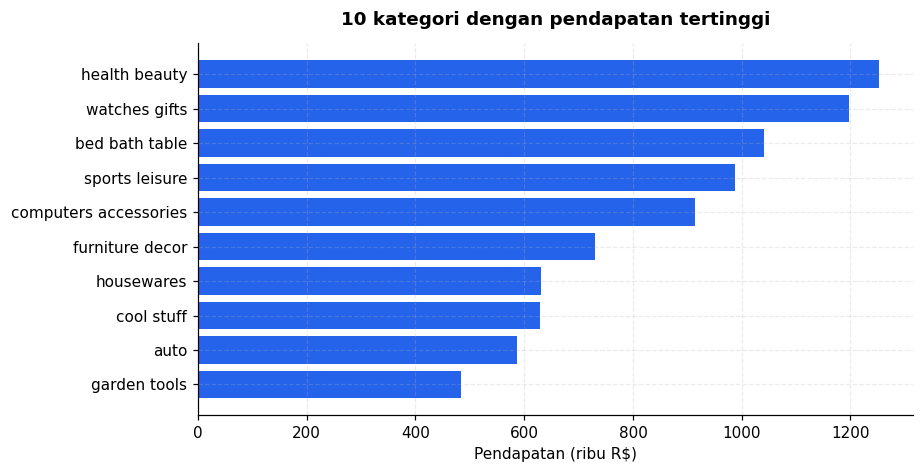

,kategori,jumlah_item,pendapatan,rata_harga,rata_skor
0,health_beauty,9645,1252404.85,129.85,4.14
1,watches_gifts,5950,1197565.48,201.27,4.02
2,bed_bath_table,11137,1040140.31,93.40,3.90
3,sports_leisure,8640,986848.92,114.22,4.11
4,computers_accessories,7849,914579.39,116.52,3.93
5,furniture_decor,8331,729864.42,87.61,3.90
6,housewares,6943,630058.22,90.75,4.06
7,cool_stuff,3772,629561.68,166.90,4.15
8,auto,4213,586669.90,139.25,4.07
9,garden_tools,4329,482946.89,111.56,4.04


In [8]:
kat = q('''
    SELECT COALESCE(t.product_category_name_english,
                    p.product_category_name) AS kategori,
           COUNT(*)                          AS jumlah_item,
           ROUND(SUM(oi.price), 2)           AS pendapatan,
           ROUND(AVG(oi.price), 2)           AS rata_harga,
           ROUND(AVG(r.review_score), 2)     AS rata_skor
    FROM order_items oi
    JOIN products p ON p.product_id = oi.product_id
    LEFT JOIN category_translation t
           ON t.product_category_name = p.product_category_name
    JOIN order_reviews r ON r.order_id = oi.order_id
    GROUP BY kategori
    ORDER BY pendapatan DESC
    LIMIT 10
''')

fig, ax = plt.subplots(figsize=(8.5, 4.4))
d = kat.iloc[::-1]
ax.barh(d.kategori.str.replace('_', ' '), d.pendapatan / 1000, color=BIRU)
ax.set_xlabel('Pendapatan (ribu R$)')
ax.set_title('10 kategori dengan pendapatan tertinggi', fontweight='bold', pad=12)
plt.show()

kat

`health_beauty` memimpin dengan pendapatan **R$ 1,25 juta**, disusul `watches_gifts`
yang punya harga satuan tertinggi (R$ 201). Skor ulasan antar kategori relatif seragam
di kisaran 3,9–4,2 — memperkuat dugaan bahwa penentu kepuasan bukan jenis produknya,
melainkan pengalaman pengirimannya.

---

## 6. Konsentrasi pendapatan penjual

Menggunakan *window function* untuk menghitung kontribusi kumulatif tiap penjual.

In [9]:
q('''
    WITH pendapatan_penjual AS (
        SELECT seller_id, SUM(price) AS pendapatan
        FROM order_items GROUP BY seller_id
    ),
    peringkat AS (
        SELECT ROW_NUMBER() OVER (ORDER BY pendapatan DESC) AS rn,
               SUM(pendapatan) OVER (ORDER BY pendapatan DESC
                                     ROWS UNBOUNDED PRECEDING) AS kumulatif,
               SUM(pendapatan) OVER () AS total,
               COUNT(*)        OVER () AS jumlah_penjual
        FROM pendapatan_penjual
    )
    SELECT '10% penjual teratas' AS segmen,
           ROUND(100.0 * MAX(kumulatif) / MAX(total), 1) AS persen_pendapatan
    FROM peringkat WHERE rn <= jumlah_penjual * 0.1
    UNION ALL
    SELECT '20% penjual teratas',
           ROUND(100.0 * MAX(kumulatif) / MAX(total), 1)
    FROM peringkat WHERE rn <= jumlah_penjual * 0.2
''')

,segmen,persen_pendapatan
0,10% penjual teratas,67.5
1,20% penjual teratas,82.7


**10% penjual teratas menghasilkan 67,5% pendapatan**, dan 20% teratas mencapai 82,7%.
Distribusi Pareto yang ekstrem dari total 3.095 penjual.

Konsekuensinya praktis: perbaikan kualitas pengiriman paling efektif bila difokuskan
pada ~300 penjual teratas, karena merekalah yang menanggung sebagian besar transaksi.

---

## Kesimpulan

| # | Temuan | Angka |
|---|---|---|
| 1 | Skor ulasan turun linear terhadap lama keterlambatan | ±0,35 poin/hari |
| 2 | Kepuasan menjadi negatif mulai hari ketiga | 2,68 pada hari ke-3 |
| 3 | Pesanan tiba terlambat | 8,11% |
| 4 | Estimasi dilebihkan dari waktu aktual | 23,7 vs 12,6 hari |
| 5 | Ulasan buruk saat telat >7 hari | 78,3% |
| 6 | Wilayah terburuk (Maranhão) | 19,1% telat |
| 7 | Konsentrasi pendapatan 10% penjual teratas | 67,5% |

## Rekomendasi

**1. Jadikan hari ketiga sebagai ambang eskalasi.**
Kerusakan reputasi terjadi pada rentang sempit dan dapat diprediksi. Pesanan yang lewat
tenggat perlu ditangani sebelum hari ketiga — melalui pemberitahuan proaktif, kompensasi
ongkir, atau percepatan pengiriman. Menunggu sampai ulasan masuk berarti sudah terlambat.

**2. Perlakukan wilayah utara dan timur laut secara terpisah.**
MA, CE, BA, dan PA memerlukan mitra logistik atau gudang penyangga tersendiri.
Menerapkan satu standar nasional menutupi masalah yang sebenarnya terpusat.

**3. Jangan perpanjang estimasi sebagai solusi.**
Cadangan 11 hari sudah diberikan dan tetap gagal pada 8% pesanan. Menambah cadangan
hanya memperburuk daya saing tanpa memperbaiki akar masalahnya.

**4. Prioritaskan 300 penjual teratas.**
Karena 10% penjual menguasai 67,5% pendapatan, pendampingan yang terfokus pada kelompok
ini memberi dampak terbesar per satuan usaha.

---

## Batasan

- Data berhenti pada Oktober 2018 dan hanya mencakup pasar Brasil.
- Hubungan yang ditemukan bersifat **korelasional**, bukan sebab-akibat: pesanan yang
  terlambat bisa jadi juga berbeda dalam hal jarak, jenis produk, atau penjual.
- Tanggal estimasi ditentukan oleh sistem Olist, bukan patokan industri.
- Pesanan yang dibatalkan sebelum sampai tidak dianalisis.